In [1]:
!pip install -U ultralytics --no-deps -q

In [2]:
from ultralytics import YOLO

# THIS SHOULD LOAD SUCCESSFULLY NOW
model = YOLO("yolov8n.pt")   # downloads official checkpoint if missing
print("Model loaded successfully:", model)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded successfully: YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias

In [3]:
import os, shutil, glob

base = "/kaggle/working/dataset"
os.makedirs(base, exist_ok=True)

def copy_dir(src, dst):
    os.makedirs(dst, exist_ok=True)
    for f in glob.glob(src + "/*"):
        shutil.copy(f, dst)

copy_dir("/kaggle/input/train-images", base + "/train/images")
copy_dir("/kaggle/input/train-labels", base + "/train/labels")

copy_dir("/kaggle/input/valid-images", base + "/valid/images")
copy_dir("/kaggle/input/valid-labels", base + "/valid/labels")

copy_dir("/kaggle/input/test-images", base + "/test/images")
copy_dir("/kaggle/input/test-labels", base + "/test/labels")

print("Dataset prepared.")


Dataset prepared.


In [4]:
data_yaml_path = "/kaggle/working/dataset/data.yaml"

yaml_text = """
path: /kaggle/working/dataset

train: train/images
val: valid/images
test: test/images

names:
  0: rust
"""

with open(data_yaml_path, "w") as f:
    f.write(yaml_text.strip())

print(open(data_yaml_path).read())


path: /kaggle/working/dataset

train: train/images
val: valid/images
test: test/images

names:
  0: rust


In [5]:
from ultralytics import YOLO
import glob, shutil, os

model = YOLO("yolov8n.pt")

model.train(
    data="/kaggle/working/dataset/data.yaml",
    epochs=40,
    batch=16,    # reduce to 8 if OOM
    imgsz=640,
    device=0,
    augment=True,
    patience=20
)

# save best
runs = sorted(glob.glob("runs/train/*"), key=os.path.getmtime)
best = os.path.join(runs[-1], "weights", "best.pt")
shutil.copy(best, "/kaggle/working/best.pt")
print("best.pt saved.")


Ultralytics 8.3.235 🚀 Python-3.11.13 torch-2.9.1+cu128 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True, pose=1

IndexError: list index out of range

In [6]:
import glob, os, shutil

# possible run dirs used by Ultralytics (detect vs train)
candidates = [
    "runs/train/*",
    "runs/detect/*",
    "/kaggle/working/runs/train/*",
    "/kaggle/working/runs/detect/*",
    "/kaggle/working/runs/*",
    "runs/*",
]

found = []
for c in candidates:
    found += glob.glob(c)

found = sorted(set(found), key=os.path.getmtime)
print("Detected run folders (latest last):")
for p in found:
    print(p)

if not found:
    raise RuntimeError("No run folders found. Check where Ultralytics saved the run (look at training logs).")

latest = found[-1]
best = os.path.join(latest, "weights", "best.pt")
print("\nLatest run:", latest)
print("Expecting best at:", best)

if os.path.exists(best):
    shutil.copy(best, "/kaggle/working/best.pt")
    print("Copied best.pt to /kaggle/working/best.pt")
else:
    # try alternative path (ultralytics sometimes uses runs/detect/train)
    alt = os.path.join(latest, "weights", "best.pt")
    if os.path.exists(alt):
        shutil.copy(alt, "/kaggle/working/best.pt")
        print("Copied best.pt to /kaggle/working/best.pt (alt path)")
    else:
        print("best.pt not found in the latest run. List files:")
        for root, dirs, files in os.walk(latest):
            print(root, len(files))
            break
        raise FileNotFoundError("best.pt not found in run weights.")


Detected run folders (latest last):
/kaggle/working/runs/detect
runs/detect
/kaggle/working/runs/detect/train
runs/detect/train

Latest run: runs/detect/train
Expecting best at: runs/detect/train/weights/best.pt
Copied best.pt to /kaggle/working/best.pt


In [7]:
import glob, collections, os

def scan_labels(path):
    files = glob.glob(os.path.join(path, "*"))
    classes = collections.Counter()
    files_with_bad_format = []
    for f in files:
        with open(f, "r", errors="ignore") as fh:
            text = fh.read().strip()
        if not text:
            continue
        for line in text.splitlines():
            parts = line.split()
            if len(parts) < 1:
                continue
            try:
                cls = int(float(parts[0]))
            except:
                files_with_bad_format.append(f)
                continue
            classes[cls] += 1
    return classes, len(files), files_with_bad_format

base = "/kaggle/working/dataset"
for split in ["train/labels", "valid/labels", "test/labels"]:
    p = os.path.join(base, split)
    classes, nfiles, bad = scan_labels(p)
    print(f"\n{split}: files={nfiles}, unique_classes={sorted(classes.keys())}, counts={dict(classes)}")
    if bad:
        print("files with unparsable lines (first 5):", bad[:5])



train/labels: files=195, unique_classes=[0, 1, 2], counts={0: 219, 1: 363, 2: 102}

valid/labels: files=42, unique_classes=[0, 1, 2], counts={0: 52, 1: 89, 2: 23}

test/labels: files=2, unique_classes=[0, 1, 2], counts={0: 2, 1: 3, 2: 1}


In [8]:
# write data.yaml for 3 classes
data_yaml = """train: /kaggle/working/dataset/train/images
val:   /kaggle/working/dataset/valid/images
test:  /kaggle/working/dataset/test/images

nc: 3
names: ['class0','class1','class2']
"""
path = "/kaggle/working/dataset/data.yaml"
with open(path, "w") as f:
    f.write(data_yaml)
print("Wrote", path)
print()
print(open(path).read())


Wrote /kaggle/working/dataset/data.yaml

train: /kaggle/working/dataset/train/images
val:   /kaggle/working/dataset/valid/images
test:  /kaggle/working/dataset/test/images

nc: 3
names: ['class0','class1','class2']



In [9]:
import glob, os, collections

# check yaml
print("data.yaml exists:", os.path.exists("/kaggle/working/dataset/data.yaml"))

# quick scan to ensure labels contain 0..2 only
def scan(path):
    cnt = collections.Counter()
    for f in glob.glob(os.path.join(path,"*.txt")):
        with open(f,"r",errors="ignore") as fh:
            for line in fh:
                p = line.split()
                if not p: 
                    continue
                try:
                    cls = int(float(p[0]))
                except:
                    continue
                cnt[cls]+=1
    return dict(cnt), len(glob.glob(os.path.join(path,"*.txt")))

for split in ["train/labels","valid/labels","test/labels"]:
    classes, n = scan("/kaggle/working/dataset/"+split)
    print(f"{split}: files={n}, classes={classes}")


data.yaml exists: True
train/labels: files=195, classes={0: 219, 1: 363, 2: 102}
valid/labels: files=42, classes={0: 52, 1: 89, 2: 23}
test/labels: files=2, classes={0: 2, 1: 3, 2: 1}


In [10]:
import glob, os, pathlib, pprint

# common locations ultralytics uses
candidates = [
    "/kaggle/working/runs/detect/*",
    "/kaggle/working/runs/*",
    "./runs/detect/*",
    "./runs/*",
    "/kaggle/working/runs/*/train/*",
]

all_runs = []
for pat in candidates:
    all_runs += glob.glob(pat)

# dedupe and sort by mtime
all_runs = sorted(list(set(all_runs)), key=os.path.getmtime) if all_runs else []
print("Found run candidate folders (oldest->newest):")
pprint.pprint(all_runs)

if all_runs:
    newest = all_runs[-1]
    print("\nNewest run folder:", newest)
    weights = glob.glob(os.path.join(newest, "weights", "*"))
    print("Files in newest/weights:", weights)
else:
    print("No runs found under common paths. If training used custom project/name, please check that path.")


Found run candidate folders (oldest->newest):
['/kaggle/working/runs/detect',
 './runs/detect',
 '/kaggle/working/runs/detect/train/args.yaml',
 '/kaggle/working/runs/detect/train/labels.jpg',
 '/kaggle/working/runs/detect/train/train_batch0.jpg',
 '/kaggle/working/runs/detect/train/weights',
 '/kaggle/working/runs/detect/train/train_batch1.jpg',
 '/kaggle/working/runs/detect/train/train_batch2.jpg',
 '/kaggle/working/runs/detect/train/train_batch30.jpg',
 '/kaggle/working/runs/detect/train/train_batch31.jpg',
 '/kaggle/working/runs/detect/train/train_batch32.jpg',
 '/kaggle/working/runs/detect/train/results.csv',
 '/kaggle/working/runs/detect/train/val_batch0_pred.jpg',
 '/kaggle/working/runs/detect/train/val_batch0_labels.jpg',
 '/kaggle/working/runs/detect/train/BoxPR_curve.png',
 '/kaggle/working/runs/detect/train/BoxF1_curve.png',
 '/kaggle/working/runs/detect/train/BoxP_curve.png',
 '/kaggle/working/runs/detect/train/BoxR_curve.png',
 '/kaggle/working/runs/detect/train/confusion_

In [11]:
import shutil, os, glob

# Try common run dir used in previous outputs
preferred_base = "/kaggle/working/runs/detect"
# find latest folder under that base (if exists), else search glob
run_dirs = sorted(glob.glob(os.path.join(preferred_base, "*")), key=os.path.getmtime) if os.path.exists(preferred_base) else []
if not run_dirs:
    run_dirs = sorted(glob.glob("runs/detect/*"), key=os.path.getmtime) + sorted(glob.glob("runs/*"), key=os.path.getmtime)

if not run_dirs:
    raise FileNotFoundError("No run directories found. Check training 'project' and 'name' args or print the run listing from the previous cell.")

run_dir = run_dirs[-1]
print("Using run_dir:", run_dir)

best = os.path.join(run_dir, "weights", "best.pt")
last = os.path.join(run_dir, "weights", "last.pt")
print("best exists:", os.path.exists(best))
print("last exists:", os.path.exists(last))

if os.path.exists(best):
    shutil.copy(best, "/kaggle/working/best.pt")
    print("Copied best.pt -> /kaggle/working/best.pt")
elif os.path.exists(last):
    shutil.copy(last, "/kaggle/working/last.pt")
    print("Copied last.pt -> /kaggle/working/last.pt")
else:
    raise FileNotFoundError(f"No weights found in {os.path.join(run_dir,'weights')}")


Using run_dir: /kaggle/working/runs/detect/train
best exists: True
last exists: True
Copied best.pt -> /kaggle/working/best.pt


In [12]:
from ultralytics import YOLO
import glob, os

wt = "/kaggle/working/best.pt"
if not os.path.exists(wt):
    # fallback to last.pt saved in working dir
    if os.path.exists("/kaggle/working/last.pt"):
        wt = "/kaggle/working/last.pt"
    else:
        raise FileNotFoundError("No /kaggle/working/best.pt or /kaggle/working/last.pt found. Run cell 2 first.")

print("Loading weights:", wt)
model = YOLO(wt)

test_images = sorted(glob.glob("/kaggle/working/dataset/test/images/*"))
print("Test images:", test_images)

# run predictions and save images/labels to runs/predict
results = model.predict(source=test_images, imgsz=640, conf=0.25, save=True, save_txt=True)

# print where predictions were saved (Ultralytics prints this too, but we show paths)
out_dirs = sorted(glob.glob("runs/predict/*"), key=os.path.getmtime)
print("Predictions saved to:", out_dirs[-1] if out_dirs else "runs/predict/<auto>")


Loading weights: /kaggle/working/best.pt
Test images: ['/kaggle/working/dataset/test/images/Fotos-buenas-133-_jpg.rf.9edebc55999a4128512f71c4ed029b55.jpg', '/kaggle/working/dataset/test/images/Fotos-buenas-9-_jpg.rf.6235eb49de2f673a512e553e0318643d.jpg']

0: 640x640 (no detections), 20.1ms
1: 640x640 (no detections), 20.1ms
Speed: 4.6ms preprocess, 20.1ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict
0 label saved to /kaggle/working/runs/detect/predict/labels
Predictions saved to: runs/predict/<auto>


In [13]:
import yaml, os
p = "/kaggle/working/dataset/data.yaml"
print("exists:", os.path.exists(p))
if os.path.exists(p):
    with open(p,'r') as f:
        d = yaml.safe_load(f)
    print("data.yaml contents:")
    print(d)
    print("nc (classes) ->", d.get("nc"))
    names = d.get("names") or d.get("labels") or d.get("class_names")
    print("names:", names)
else:
    print("data.yaml not found at", p)


exists: True
data.yaml contents:
{'train': '/kaggle/working/dataset/train/images', 'val': '/kaggle/working/dataset/valid/images', 'test': '/kaggle/working/dataset/test/images', 'nc': 3, 'names': ['class0', 'class1', 'class2']}
nc (classes) -> 3
names: ['class0', 'class1', 'class2']


In [14]:
import glob, os, pprint
pred_dir = "/kaggle/working/runs/detect/predict"
print("exists:", os.path.exists(pred_dir))
print("files in predict folder:")
pprint.pprint(glob.glob(os.path.join(pred_dir, "**"), recursive=False)[:40])

label_dir = os.path.join(pred_dir, "labels")
print("\nlabel dir exists:", os.path.exists(label_dir))
labels = sorted(glob.glob(os.path.join(label_dir,"*.txt")))
print("saved label files:", labels)
for lf in labels:
    print("----", os.path.basename(lf))
    print(open(lf).read().strip() or "<empty>")


exists: True
files in predict folder:
['/kaggle/working/runs/detect/predict/Fotos-buenas-9-_jpg.rf.6235eb49de2f673a512e553e0318643d.jpg',
 '/kaggle/working/runs/detect/predict/labels',
 '/kaggle/working/runs/detect/predict/Fotos-buenas-133-_jpg.rf.9edebc55999a4128512f71c4ed029b55.jpg']

label dir exists: True
saved label files: []


In [15]:
import os, glob, pprint
print("best.pt exists:", os.path.exists("/kaggle/working/best.pt"))
print("runs detect folders (most recent last):")
for p in sorted(glob.glob("/kaggle/working/runs/detect/*"), key=os.path.getmtime):
    print(" ", p)
print("weights in runs/detect/*/weights:")
pprint.pprint(sorted(glob.glob("/kaggle/working/runs/detect/*/weights/*"), key=os.path.getmtime))


best.pt exists: True
runs detect folders (most recent last):
  /kaggle/working/runs/detect/train
  /kaggle/working/runs/detect/predict
weights in runs/detect/*/weights:
['/kaggle/working/runs/detect/train/weights/last.pt',
 '/kaggle/working/runs/detect/train/weights/best.pt']


using weights: /kaggle/working/best.pt exists? True
test_images: ['/kaggle/working/dataset/test/images/Fotos-buenas-133-_jpg.rf.9edebc55999a4128512f71c4ed029b55.jpg', '/kaggle/working/dataset/test/images/Fotos-buenas-9-_jpg.rf.6235eb49de2f673a512e553e0318643d.jpg']

0: 640x640 10 rusts, 6.5ms
1: 640x640 5 rusts, 6.5ms
Speed: 3.4ms preprocess, 6.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict2
2 labels saved to /kaggle/working/runs/detect/predict2/labels
predict out exists: True
files: ['Fotos-buenas-133-_jpg.rf.9edebc55999a4128512f71c4ed029b55.jpg', 'Fotos-buenas-9-_jpg.rf.6235eb49de2f673a512e553e0318643d.jpg', 'labels']
labels dir exists: True
label files: []
Displaying /kaggle/working/runs/detect/predict/Fotos-buenas-133-_jpg.rf.9edebc55999a4128512f71c4ed029b55.jpg


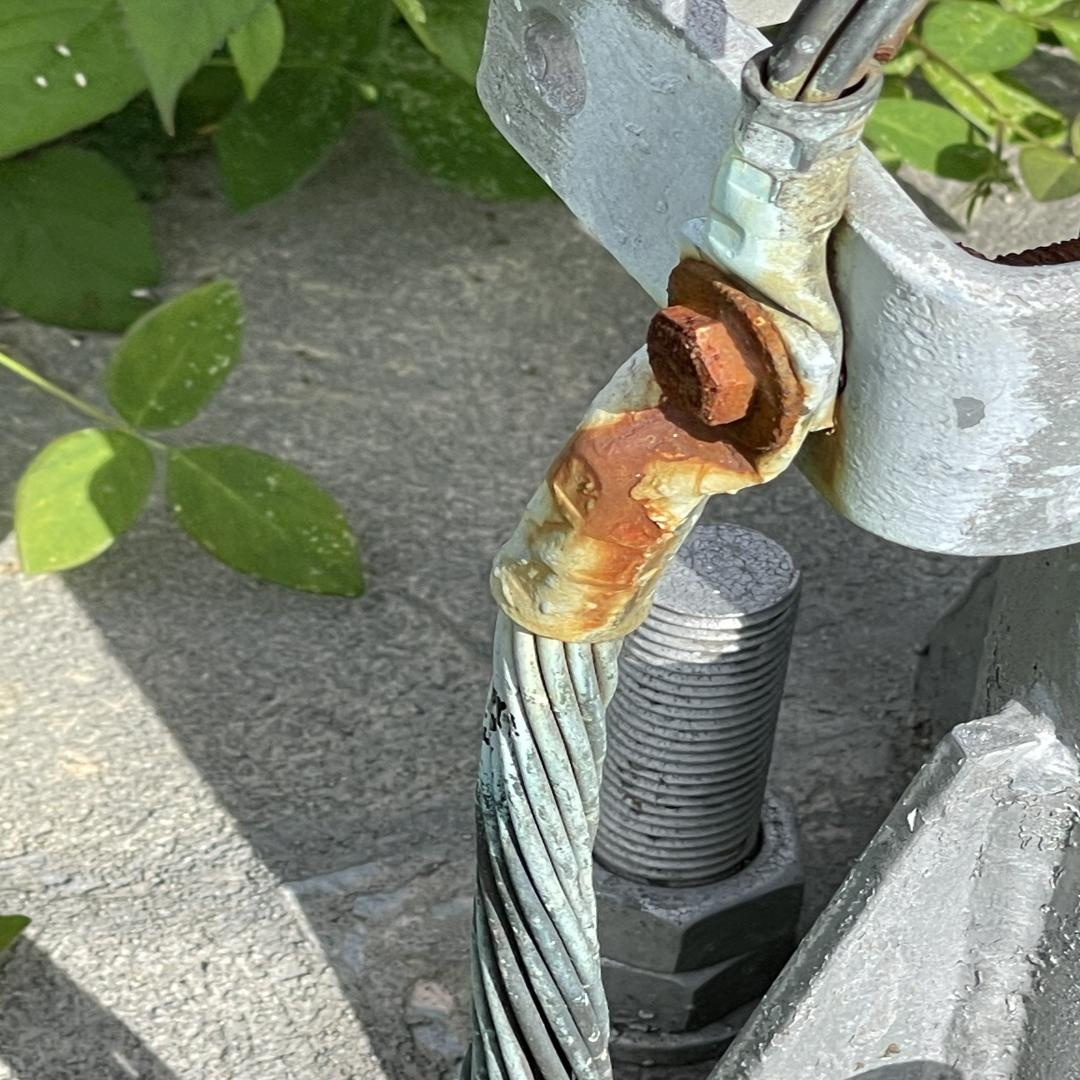

Displaying /kaggle/working/runs/detect/predict/Fotos-buenas-9-_jpg.rf.6235eb49de2f673a512e553e0318643d.jpg


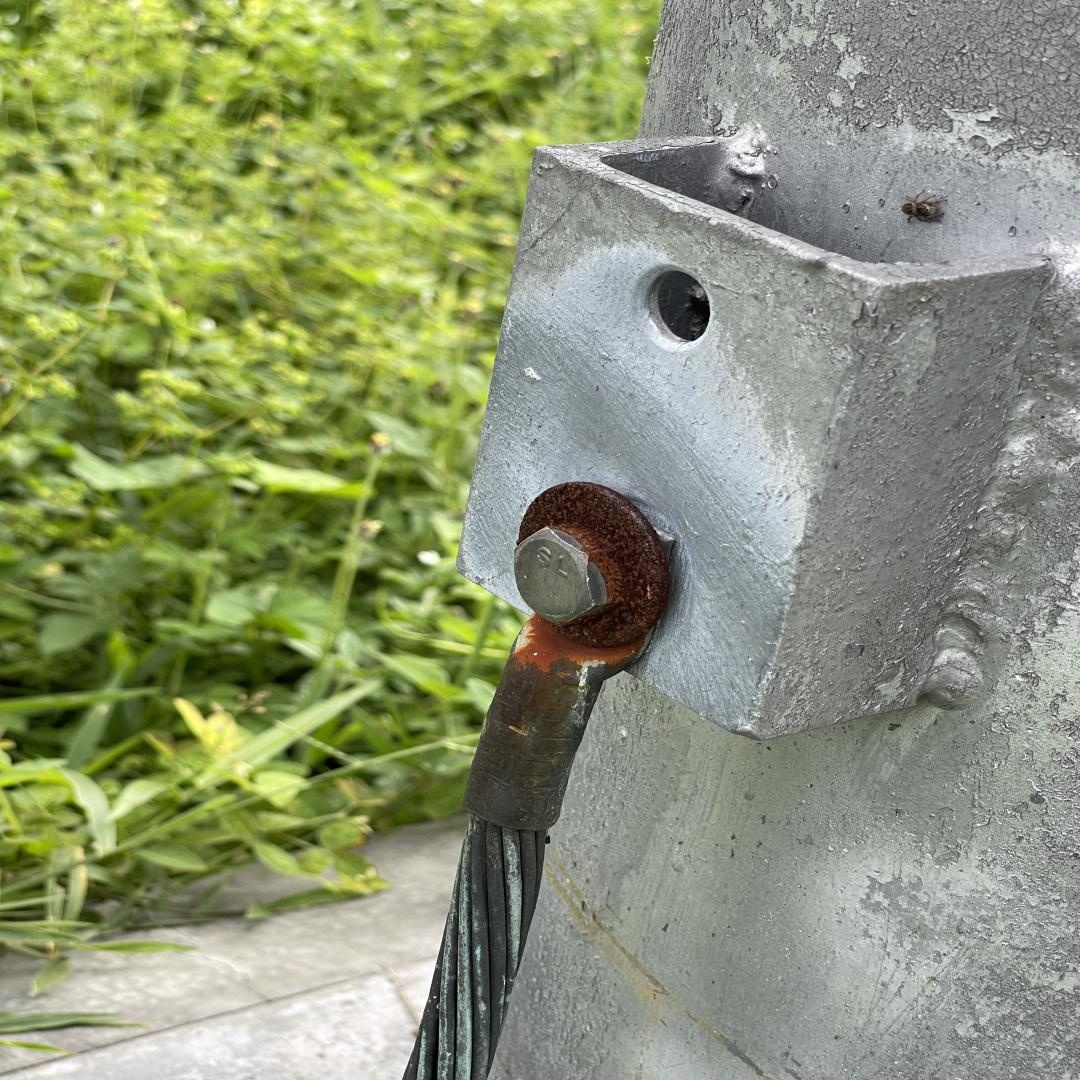

In [16]:
from ultralytics import YOLO
import glob, os, shutil, IPython.display as D

wt = "/kaggle/working/best.pt"   # change path if different
print("using weights:", wt, "exists?", os.path.exists(wt))
model = YOLO(wt)

test_images = sorted(glob.glob("/kaggle/working/dataset/test/images/*"))
print("test_images:", test_images)

# run predict with a very low conf to reveal weak detections
res = model.predict(source=test_images, imgsz=640, conf=0.01, iou=0.2,
                    save=True, save_txt=True, save_conf=True, device=0)

# show the output folder contents
out = "/kaggle/working/runs/detect/predict"
print("predict out exists:", os.path.exists(out))
print("files:", sorted(os.listdir(out)))
print("labels dir exists:", os.path.exists(os.path.join(out,"labels")))
print("label files:", sorted(glob.glob(os.path.join(out,"labels","*.txt"))))
# display the two saved images
for f in sorted(glob.glob(os.path.join(out,"*.jpg"))):
    print("Displaying", f)
    display(D.Image(f))


In [17]:
import os, glob, pprint

for d in sorted(glob.glob("/kaggle/working/runs/detect/*")):
    print("FOLDER:", d)
    print("  files:", sorted(os.listdir(d)))
    lbls = sorted(glob.glob(os.path.join(d,"labels","*.txt"))) if os.path.exists(os.path.join(d,"labels")) else []
    print("  label count:", len(lbls))
    if lbls:
        print("   first 3 label files:", lbls[:3])
    print()


FOLDER: /kaggle/working/runs/detect/predict
  files: ['Fotos-buenas-133-_jpg.rf.9edebc55999a4128512f71c4ed029b55.jpg', 'Fotos-buenas-9-_jpg.rf.6235eb49de2f673a512e553e0318643d.jpg', 'labels']
  label count: 0

FOLDER: /kaggle/working/runs/detect/predict2
  files: ['Fotos-buenas-133-_jpg.rf.9edebc55999a4128512f71c4ed029b55.jpg', 'Fotos-buenas-9-_jpg.rf.6235eb49de2f673a512e553e0318643d.jpg', 'labels']
  label count: 2
   first 3 label files: ['/kaggle/working/runs/detect/predict2/labels/Fotos-buenas-133-_jpg.rf.9edebc55999a4128512f71c4ed029b55.txt', '/kaggle/working/runs/detect/predict2/labels/Fotos-buenas-9-_jpg.rf.6235eb49de2f673a512e553e0318643d.txt']

FOLDER: /kaggle/working/runs/detect/train
  files: ['BoxF1_curve.png', 'BoxPR_curve.png', 'BoxP_curve.png', 'BoxR_curve.png', 'args.yaml', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'labels.jpg', 'results.csv', 'results.png', 'train_batch0.jpg', 'train_batch1.jpg', 'train_batch2.jpg', 'train_batch30.jpg', 'train_batch31.

In [18]:
import glob, os
lbl_dir = "/kaggle/working/runs/detect/predict2/labels"
print("label_dir exists:", os.path.exists(lbl_dir))
files = sorted(glob.glob(os.path.join(lbl_dir,"*.txt")))
print("label files:", files)
for p in files:
    print("\n---", os.path.basename(p))
    with open(p,'r') as f:
        data = f.read().strip()
        if not data:
            print("(empty file)")
        else:
            print(data)


label_dir exists: True
label files: ['/kaggle/working/runs/detect/predict2/labels/Fotos-buenas-133-_jpg.rf.9edebc55999a4128512f71c4ed029b55.txt', '/kaggle/working/runs/detect/predict2/labels/Fotos-buenas-9-_jpg.rf.6235eb49de2f673a512e553e0318643d.txt']

--- Fotos-buenas-133-_jpg.rf.9edebc55999a4128512f71c4ed029b55.txt
0 0.640929 0.5 0.718142 1 0.0218454
0 0.0791027 0.0833393 0.157642 0.163346 0.0120973
0 0.847564 0.125669 0.297971 0.246763 0.0120309
0 0.323838 0.248407 0.624706 0.486761 0.0114254
0 0.220871 0.74692 0.441742 0.495654 0.0106988
0 0.833575 0.806503 0.332849 0.375213 0.0105819
0 0.577862 0.138343 0.267695 0.276687 0.0105324
0 0.293986 0.0385388 0.235737 0.0770775 0.0103044
0 0.0936763 0.922155 0.187353 0.15569 0.0101017
0 0.865091 0.435047 0.269817 0.50999 0.0100925

--- Fotos-buenas-9-_jpg.rf.6235eb49de2f673a512e553e0318643d.txt
0 0.603488 0.5 0.784098 1 0.0198169
0 0.258461 0.335856 0.515378 0.592951 0.0110383
0 0.0849936 0.0556602 0.169987 0.11132 0.0108894
0 0.836286 0

In [20]:
!mkdir -p /kaggle/working/runs/detect/predict/labels
!cp /kaggle/working/runs/detect/predict2/labels/*.txt /kaggle/working/runs/detect/predict/labels/
!ls -l /kaggle/working/runs/detect/predict/labels


total 8
-rw-r--r-- 1 root root 470 Dec  5 16:32 Fotos-buenas-133-_jpg.rf.9edebc55999a4128512f71c4ed029b55.txt
-rw-r--r-- 1 root root 228 Dec  5 16:32 Fotos-buenas-9-_jpg.rf.6235eb49de2f673a512e553e0318643d.txt


In [26]:
# Quick runtime patch + safe validation (no plotting)
from ultralytics import YOLO
import yaml, pprint

data_yaml = "/kaggle/working/dataset/data.yaml"

with open(data_yaml) as f:
    data = yaml.safe_load(f)

model = YOLO("/kaggle/working/best.pt")

# desired dataset values
desired_nc   = int(data.get("nc", len(data.get("names", []))))
desired_names = data.get("names", [f"class{i}" for i in range(desired_nc)])
if isinstance(desired_names, list):
    desired_names = {i: n for i, n in enumerate(desired_names)}

print("Before patch: wrapper nc:", getattr(model, "nc", None), "wrapper names:", getattr(model, "names", None))
print(" underlying nc:", getattr(getattr(model, "model", None), "nc", None),
      " underlying names:", getattr(getattr(model, "model", None), "names", None))

# apply patch to underlying model only (safe)
try:
    setattr(model.model, "nc", desired_nc)
    setattr(model.model, "names", desired_names)
except Exception as e:
    print("Warning setting underlying model attributes:", e)

# remove problematic entries from args (defensive)
try:
    if isinstance(getattr(model.model, "args", None), dict):
        for k in ("nc", "names"):
            if k in model.model.args:
                model.model.args.pop(k, None)
except Exception as e:
    print("Warning cleaning model.model.args:", e)

print("After patch: wrapper nc:", getattr(model, "nc", None), "wrapper names:", getattr(model, "names", None))
print(" underlying nc:", getattr(getattr(model, "model", None), "nc", None),
      " underlying names:", getattr(getattr(model, "model", None), "names", None))

# Run validation with plots=False to avoid confusion matrix plotting which caused the IndexError
print("\nRunning validation (plots=False)...")
metrics = model.val(data=data_yaml, split="test", plots=False)
pprint.pprint(metrics)


Before patch: wrapper nc: 1 wrapper names: {0: 'rust'}
 underlying nc: 1  underlying names: {0: 'rust'}
After patch: wrapper nc: 3 wrapper names: {0: 'class0', 1: 'class1', 2: 'class2'}
 underlying nc: 3  underlying names: {0: 'class0', 1: 'class1', 2: 'class2'}

Running validation (plots=False)...
Ultralytics 8.3.235 🚀 Python-3.11.13 torch-2.9.1+cu128 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2529.0±1338.7 MB/s, size: 194.4 KB)
val: Scanning /kaggle/working/dataset/test/labels.cache... 2 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2/2 4.0Kit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 14.8it/s 0.1s
                   all          2          6    0.00111      0.333      0.332      0.182
                class0          2          2    0.00333          1      0.995      0.547
              

In [27]:
# from your notebook shell or Kaggle cell
!yolo detect train model=yolov8n.pt data=/kaggle/working/dataset/data.yaml epochs=20 imgsz=640 batch=16


Ultralytics 8.3.235 🚀 Python-3.11.13 torch-2.9.1+cu128 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pos

In [29]:
%%bash
cat > /kaggle/working/check_labels.py <<'PY'
import sys
import os

root = sys.argv[1] if len(sys.argv)>1 else "."
expected_nc = int(sys.argv[2]) if len(sys.argv)>2 else None

def find_label_files(path):
    for dirpath,_,filenames in os.walk(path):
        for f in filenames:
            if f.endswith('.txt'):
                if f.endswith('.cache'):
                    continue
                yield os.path.join(dirpath, f)

label_files = list(find_label_files(root))
print(f"Found {len(label_files)} label files under {root}")

all_classes = set()
bad_files = []
for lf in label_files:
    with open(lf, 'r', encoding='utf-8', errors='ignore') as fh:
        for line_no,line in enumerate(fh,1):
            line=line.strip()
            if not line:
                continue
            parts=line.split()
            try:
                cls = int(float(parts[0]))
            except Exception as e:
                print(f"Could not parse class id in {lf}:{line_no} -> {line}")
                continue
            all_classes.add(cls)
            if expected_nc is not None and (cls < 0 or cls >= expected_nc):
                bad_files.append((lf, line_no, cls))

print("Unique class ids found:", sorted(all_classes))
if expected_nc is not None:
    print(f"Expected nc = {expected_nc}; allowed ids 0..{expected_nc-1}")
if bad_files:
    echo_count=0
    print("\nFiles with out-of-range class ids (file, line, class):")
    for bf in bad_files[:200]:
        print(bf)
else:
    print("No out-of-range class ids detected.")
PY

# run it (change nc if needed)
python /kaggle/working/check_labels.py /kaggle/working/dataset 3


Found 395 label files under /kaggle/working/dataset
Unique class ids found: [0, 1, 2]
Expected nc = 3; allowed ids 0..2
No out-of-range class ids detected.


In [32]:
# Paste this entire cell into a notebook (Kaggle/Colab/Jupyter) and run.
# It will scan labels under ROOT, copy images into per-class folders (if COPY=True),
# write a label_summary.csv and optionally write data.yaml with class names.
#
# Edit ROOT, OUT_DIR, COPY, WRITE_DATA_YAML as needed.

import os, shutil, csv
from pathlib import Path

# --------- CONFIGURE HERE ----------
ROOT = Path("/kaggle/working/dataset")   # dataset root (images + .txt labels)
OUT_DIR = ROOT / "by_class"             # where per-class folders and CSV will be created
COPY = True                             # copy images into per-class folders (False = only report)
WRITE_DATA_YAML = True                  # write data.yaml into ROOT if True
CLASS_NAMES = ['healthy', 'moderate', 'critical']  # class names for ids 0,1,2
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
# ------------------------------------

EXPECTED_NC = len(CLASS_NAMES)

def find_label_files(root:Path):
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            fname = f.lower()
            if fname.endswith('.txt') and not fname.endswith('.cache'):
                yield Path(dirpath) / f

def find_image_for_label(label_path:Path, root:Path):
    base = label_path.stem
    parent = label_path.parent
    candidates = []
    # 1) same folder check
    for ext in IMG_EXTS:
        p = parent / (base + ext)
        if p.exists():
            candidates.append(p)
    # 2) search dataset tree for same stem (fallback)
    if not candidates:
        for dirpath, _, filenames in os.walk(root):
            for fname in filenames:
                if Path(fname).suffix.lower() in IMG_EXTS and Path(fname).stem == base:
                    candidates.append(Path(dirpath) / fname)
    return candidates

def parse_label_file(path:Path):
    classes = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as fh:
        for i, line in enumerate(fh,1):
            s = line.strip()
            if not s: 
                continue
            parts = s.split()
            try:
                cls = int(float(parts[0]))
            except Exception:
                print(f"WARNING: could not parse class id in {path}:{i} -> '{s}'")
                continue
            classes.append(cls)
    return sorted(set(classes))

def write_data_yaml(root:Path):
    content = f"nc: {EXPECTED_NC}\nnames: {CLASS_NAMES}\n"
    p = root / "data.yaml"
    p.write_text(content, encoding='utf-8')
    return p

def main():
    root = ROOT
    out_dir = OUT_DIR
    if not root.exists():
        print(f"ERROR: ROOT path does not exist: {root}")
        return

    if COPY:
        out_dir.mkdir(parents=True, exist_ok=True)

    class_dirs = {}
    for idx, cname in enumerate(CLASS_NAMES):
        d = out_dir / cname
        if COPY:
            d.mkdir(parents=True, exist_ok=True)
        class_dirs[idx] = d

    label_files = list(find_label_files(root))
    print(f"Found {len(label_files)} label files under {root}")

    counts = {i:0 for i in range(EXPECTED_NC)}
    files_without_image = []
    images_with_no_label = []
    summary_rows = []

    for lf in label_files:
        classes = parse_label_file(lf)
        for c in classes:
            if c < 0 or c >= EXPECTED_NC:
                print(f"ERROR: out-of-range class id {c} in {lf}")
        img_candidates = find_image_for_label(lf, root)
        if not img_candidates:
            files_without_image.append(str(lf))
            continue
        # handle each image candidate (usually 1)
        for img_path in img_candidates:
            class_names = [CLASS_NAMES[c] for c in classes if 0 <= c < EXPECTED_NC]
            if not class_names:
                images_with_no_label.append(str(img_path))
            else:
                for c in classes:
                    if 0 <= c < EXPECTED_NC:
                        counts[c] += 1
                        if COPY:
                            dst = class_dirs[c] / img_path.name
                            if dst.exists():
                                base = dst.stem
                                ext = dst.suffix
                                i = 1
                                while (class_dirs[c] / f"{base}_{i}{ext}").exists():
                                    i += 1
                                dst = class_dirs[c] / f"{base}_{i}{ext}"
                            try:
                                shutil.copy2(img_path, dst)
                            except Exception as e:
                                print(f"WARNING: failed to copy {img_path} -> {dst}: {e}")
            summary_rows.append((str(img_path), ",".join(class_names)))

    # write CSV
    if COPY:
        csv_path = out_dir / 'label_summary.csv'
    else:
        out_dir.mkdir(parents=True, exist_ok=True)
        csv_path = out_dir / 'label_summary.csv'
    with open(csv_path, 'w', newline='', encoding='utf-8') as csvf:
        writer = csv.writer(csvf)
        writer.writerow(['image_path','classes'])
        for row in summary_rows:
            writer.writerow(row)

    print("\nClass counts (images assigned per class):")
    for idx, cname in enumerate(CLASS_NAMES):
        print(f"  {idx} ({cname}): {counts.get(idx,0)}")

    if files_without_image:
        print(f"\nWARNING: {len(files_without_image)} label files had no matching image. Example: {files_without_image[:5]}")
    if images_with_no_label:
        print(f"\nNOTE: {len(images_with_no_label)} images with empty or missing labels. Example: {images_with_no_label[:5]}")

    print(f"\nSummary CSV written to: {csv_path}")
    if COPY:
        print(f"Images copied into per-class folders at: {out_dir}")
    else:
        print(f"Per-class folders were NOT created (set COPY=True to copy images)")

    if WRITE_DATA_YAML:
        data_yaml_path = write_data_yaml(root)
        print(f"\nWrote data.yaml -> {data_yaml_path}")
        print(data_yaml_path.read_text())

# Run
main()


Found 395 label files under /kaggle/working/dataset

Class counts (images assigned per class):
  0 (healthy): 877
  1 (moderate): 903
  2 (critical): 457

Summary CSV written to: /kaggle/working/dataset/by_class/label_summary.csv
Images copied into per-class folders at: /kaggle/working/dataset/by_class

Wrote data.yaml -> /kaggle/working/dataset/data.yaml
nc: 3
names: ['healthy', 'moderate', 'critical']



In [34]:
# Paste entire cell and run.

import csv, random, os
from pathlib import Path
random.seed(42)

ROOT = Path("/kaggle/working/dataset")
BY_CLASS_DIR = ROOT / "by_class"
CSV = BY_CLASS_DIR / "label_summary.csv"
OUT_SPLIT_DIR = ROOT / "splits"
TRAIN_RATIO = 0.8

CLASS_NAMES = ['healthy', 'moderate', 'critical']
NAME_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}

# ------------------ READ CSV ------------------

rows = []
with open(CSV, newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for r in reader:
        rows.append((r['image_path'], r['classes']))

print(f"Total rows in summary: {len(rows)}")

parsed = []

for img_path, classes in rows:
    if not classes.strip():
        continue

    cl_list = [c.strip() for c in classes.split(',') if c.strip()]

    # Convert class names → IDs
    try:
        cls_ids = [NAME_TO_ID[c] for c in cl_list]
    except KeyError as e:
        raise ValueError(f"Unknown class name in CSV: {e}")

    primary = cls_ids[0]
    parsed.append((img_path, primary, cls_ids))

# ------------------ GROUP BY CLASS ------------------

by_class = {}
for img, primary, cls_ids in parsed:
    by_class.setdefault(primary, []).append(img)

print("\nImage counts (per primary class):")
for cid in range(len(CLASS_NAMES)):
    print(f"  {cid} ({CLASS_NAMES[cid]}): {len(by_class.get(cid, []))}")

# ------------------ STRATIFIED SPLIT ------------------

train_list = []
val_list = []

for cid, imglist in by_class.items():
    shuffled = imglist.copy()
    random.shuffle(shuffled)
    n_train = int(len(shuffled) * TRAIN_RATIO)
    train_list += [(p, cid) for p in shuffled[:n_train]]
    val_list   += [(p, cid) for p in shuffled[n_train:]]

random.shuffle(train_list)
random.shuffle(val_list)

OUT_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

train_txt = OUT_SPLIT_DIR / "train.txt"
val_txt = OUT_SPLIT_DIR / "val.txt"

with open(train_txt, 'w') as f:
    for p, _ in train_list:
        f.write(str(Path(p).resolve()) + '\n')

with open(val_txt, 'w') as f:
    for p, _ in val_list:
        f.write(str(Path(p).resolve()) + '\n')

print(f"\nTrain entries: {len(train_list)}")
print(f"Val entries:   {len(val_list)}")
print(f"train.txt saved → {train_txt}")
print(f"val.txt saved   → {val_txt}")

# ------------------ SHOW SAMPLE ------------------

def show_sample(title, lst, max_per_class=2):
    print(f"\n{title} sample (max {max_per_class} per class):")
    grouped = {}
    for p, cid in lst:
        grouped.setdefault(cid, []).append(p)
    for cid in grouped:
        sample = grouped[cid][:max_per_class]
        print(f"  {cid} ({CLASS_NAMES[cid]}) → {sample}")

show_sample("TRAIN", train_list)
show_sample("VAL", val_list)


Total rows in summary: 926

Image counts (per primary class):
  0 (healthy): 877
  1 (moderate): 49
  2 (critical): 0

Train entries: 740
Val entries:   186
train.txt saved → /kaggle/working/dataset/splits/train.txt
val.txt saved   → /kaggle/working/dataset/splits/val.txt

TRAIN sample (max 2 per class):
  0 (healthy) → ['/kaggle/working/dataset/by_class/critical/Fotos-buenas-119-_jpg.rf.f427c18082c8c76fa48c51b2f889b1d3.jpg', '/kaggle/working/dataset/train/images/Fotos-buenas-135-_jpg.rf.b54cfbc482eb306c3a4c6e5d5f6e6bf2.jpg']
  1 (moderate) → ['/kaggle/working/dataset/train/images/Fotos-buenas-62-_JPG.rf.c44623016c96aa4b4facce97917bb596.jpg', '/kaggle/working/dataset/valid/images/Fotos-buenas-63-_JPG.rf.ecd8f89766cddb4900bd7ce66a1c72a0.jpg']

VAL sample (max 2 per class):
  0 (healthy) → ['/kaggle/working/dataset/by_class/moderate/Fotos-buenas-1-_jpg.rf.9f0b8d85ef7198d7b2ec4accf6d8cb29.jpg', '/kaggle/working/dataset/by_class/healthy/Fotos-buenas-134-_jpg.rf.8f2b92f3b116ce1172d1b56dbe29

In [35]:
# Copy-paste this entire cell into a Kaggle notebook and run.

import os, shutil, csv
from pathlib import Path
import sys

ROOT = Path("/kaggle/working/dataset")   # change if your dataset root differs
LABEL_EXT = ".txt"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".JPG", ".JPEG", ".PNG"}

# --- adjust these names if you want different labels ---
CLASS_NAMES = ['healthy', 'moderate', 'critical']
NAME_TO_ID = {n: i for i, n in enumerate(CLASS_NAMES)}
ID_TO_NAME = {i: n for i, n in enumerate(CLASS_NAMES)}

# --- output folders (safe: does not overwrite original by_class) ---
OUT_BY_CLASS = ROOT / "corrected_by_class"
OUT_BY_CLASS.mkdir(parents=True, exist_ok=True)

SUMMARY_CSV = ROOT / "corrected_label_summary.csv"
DATA_YAML = ROOT / "data.yaml"

def find_label_for_image(img_path):
    # label file typically same name with .txt
    p = Path(img_path)
    lab = p.with_suffix(LABEL_EXT)
    if lab.exists():
        return lab
    # sometimes image names have additional suffixes; try same basename search
    for ext in IMAGE_EXTS:
        candidate = p.with_suffix(LABEL_EXT)
        if candidate.exists():
            return candidate
    return None

def parse_label_file(label_path):
    """
    Returns list of class ids (ints) found in label file,
    interpreting either numeric ids (0,1,2...) or class names (healthy,...).
    If file empty or no classes: returns [].
    """
    cls_ids = []
    with open(label_path, "r", encoding="utf-8", errors="ignore") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            tok = parts[0]
            # try numeric first
            try:
                cid = int(float(tok))
                cls_ids.append(cid)
            except Exception:
                # treat as name (strip punctuation)
                tok_clean = tok.strip().lower()
                # map name to id if possible
                if tok_clean in NAME_TO_ID:
                    cls_ids.append(NAME_TO_ID[tok_clean])
                else:
                    # fall back: maybe label file uses capitalized names, or different language
                    for name in NAME_TO_ID:
                        if tok_clean == name.lower():
                            cls_ids.append(NAME_TO_ID[name])
                            break
                    else:
                        # unknown token — warn and skip
                        print(f"Warning: unknown class token '{tok}' in {label_path}; skipping that token.")
                        continue
    return cls_ids

# --- collect all images under root (scan train/valid/by_class folders) ---
image_paths = []
for dirpath, _, filenames in os.walk(ROOT):
    # skip the output folder we are creating
    if str(OUT_BY_CLASS) in dirpath:
        continue
    # skip cache/YOLO run dirs
    if "runs" in dirpath or ".cache" in dirpath or "by_class" in dirpath and "corrected_by_class" not in dirpath:
        # still allow label scanning if necessary, but ignore run outputs
        pass
    for f in filenames:
        ext = Path(f).suffix
        if ext.lower() in IMAGE_EXTS:
            image_paths.append(Path(dirpath) / f)

print(f"Found {len(image_paths)} image files under {ROOT}")

rows = []  # will hold tuples (src_image_path, classes_as_ids)

missing_label_images = []
no_classes_images = []

for img in image_paths:
    lab = img.with_suffix(LABEL_EXT)
    if not lab.exists():
        missing_label_images.append(str(img))
        continue
    cls_ids = parse_label_file(lab)
    if not cls_ids:
        no_classes_images.append(str(img))
        continue
    rows.append((str(img), cls_ids))

print(f"Images with no label file: {len(missing_label_images)}")
print(f"Images with empty/unsuccessful labels: {len(no_classes_images)}")
print(f"Images with parsed labels: {len(rows)}")

# --- copy images into corrected_by_class/<classname>/ taking primary (first) class ---
from collections import defaultdict
by_class = defaultdict(list)

for img_path, cls_ids in rows:
    primary = cls_ids[0]  # primary class = first listed
    if primary not in ID_TO_NAME:
        print(f"Warning: primary class id {primary} not in ID_TO_NAME mapping for {img_path}; skipping")
        continue
    cname = ID_TO_NAME[primary]
    dest_dir = OUT_BY_CLASS / cname
    dest_dir.mkdir(parents=True, exist_ok=True)
    src = Path(img_path)
    dest = dest_dir / src.name
    try:
        shutil.copy2(src, dest)
    except Exception as e:
        print(f"Failed copying {src} -> {dest}: {e}")
        continue
    by_class[primary].append(str(dest))

# --- write corrected summary CSV ---
with open(SUMMARY_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["image_path", "classes"])  # classes as comma-separated names
    for img_path, cls_ids in rows:
        names = ",".join(ID_TO_NAME.get(cid, str(cid)) for cid in cls_ids)
        writer.writerow([img_path, names])

# --- write data.yaml (overwrites previous data.yaml) ---
yaml_text = f"nc: {len(CLASS_NAMES)}\nnames: {CLASS_NAMES}\n"
DATA_YAML.write_text(yaml_text, encoding="utf-8")

# --- report counts and samples ---
print("\nClass counts after correction:")
total = 0
for cid in range(len(CLASS_NAMES)):
    cnt = len(by_class.get(cid, []))
    total += cnt
    print(f"  {cid} ({CLASS_NAMES[cid]}): {cnt}")
print(f"Total images copied into corrected_by_class: {total}")

# show sample files per class
print("\nSample files (up to 3 per class):")
for cid in range(len(CLASS_NAMES)):
    sample = by_class.get(cid, [])[:3]
    print(f"  {cid} ({CLASS_NAMES[cid]}) -> {sample}")

print(f"\nSummary CSV written to: {SUMMARY_CSV}")
print(f"Data yaml written to: {DATA_YAML}")
print(f"Images copied into per-class folders at: {OUT_BY_CLASS}")

# optionally: list a few missing-label files for manual inspection
if missing_label_images:
    print("\nFirst 10 images missing label files:")
    for p in missing_label_images[:10]:
        print("  ", p)
if no_classes_images:
    print("\nFirst 10 images whose label files contained no recognized classes:")
    for p in no_classes_images[:10]:
        print("  ", p)


Found 2476 image files under /kaggle/working/dataset
Images with no label file: 2476
Images with empty/unsuccessful labels: 0
Images with parsed labels: 0

Class counts after correction:
  0 (healthy): 0
  1 (moderate): 0
  2 (critical): 0
Total images copied into corrected_by_class: 0

Sample files (up to 3 per class):
  0 (healthy) -> []
  1 (moderate) -> []
  2 (critical) -> []

Summary CSV written to: /kaggle/working/dataset/corrected_label_summary.csv
Data yaml written to: /kaggle/working/dataset/data.yaml
Images copied into per-class folders at: /kaggle/working/dataset/corrected_by_class

First 10 images missing label files:
   /kaggle/working/dataset/train/images/Fotos-buenas-128-_jpg.rf.c7cc1aeeeb09a52af7adbabaf564aed4.jpg
   /kaggle/working/dataset/train/images/Fotos-buenas-117-_jpg.rf.d206eb3c77d8c6501da399fc5e4af5cb.jpg
   /kaggle/working/dataset/train/images/Fotos-buenas-15-_jpg.rf.e7763834dcbf6901c4a70b3d82e8c9da.jpg
   /kaggle/working/dataset/train/images/Fotos-buenas-113

In [36]:
# Paste this entire cell into a Kaggle notebook and run.

import os
from pathlib import Path
import shutil

ROOT = Path("/kaggle/working/dataset")   # adjust if needed
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".JPG", ".JPEG"}
LABEL_EXT = ".txt"
COPY_LABELS_NEXT_TO_IMAGES = True   # set False if you don't want labels copied

# 1) find all images and all .txt label files
image_paths = []
label_paths = []

for dirpath, _, files in os.walk(ROOT):
    # skip run outputs
    if "runs" in dirpath.split(os.sep):
        continue
    for f in files:
        p = Path(dirpath) / f
        if p.suffix.lower() in IMAGE_EXTS:
            image_paths.append(p)
        elif p.suffix.lower() == LABEL_EXT:
            label_paths.append(p)

print(f"Found {len(image_paths)} image files under {ROOT}")
print(f"Found {len(label_paths)} label (.txt) files under {ROOT}")
if len(label_paths) > 0:
    print("Example label files:")
    for lp in label_paths[:10]:
        print(" ", lp)

# build fast lookup maps for labels
labels_by_name = {}          # key = filename without suffix (full name), value = list(paths)
labels_by_stem = {}          # key = Path.stem (everything before last dot), val list(paths)
labels_by_rf_stripped = {}   # key = stem with '.rf.' and following removed

for lp in label_paths:
    name = lp.name  # e.g. Fotos-buenas-1-_jpeg.rf.09e9d26e474d2598527fc3ae1bb16802.txt
    stem = lp.stem  # same without .txt
    labels_by_name.setdefault(name, []).append(lp)
    labels_by_stem.setdefault(stem, []).append(lp)
    # create rf-stripped key
    s = stem
    if ".rf." in s:
        stripped = s.split(".rf.")[0]
        labels_by_rf_stripped.setdefault(stripped, []).append(lp)
    # also try splitting at last dot and take first part
    if "." in s:
        firstpart = s.split(".")[0]
        labels_by_rf_stripped.setdefault(firstpart, []).append(lp)

# matching heuristics
matched = {}   # image_path -> label_path (best match)
unmatched = []

def try_match_for_image(img_path):
    # heuristics in order, return label Path or None
    img = Path(img_path)
    name = img.name
    stem = img.stem
    # 1) exact same filename with .txt in same directory
    cand = img.with_suffix(LABEL_EXT)
    if cand.exists():
        return cand
    # 2) label with same filename anywhere
    if name.replace(img.suffix, LABEL_EXT) in labels_by_name:
        return labels_by_name[name.replace(img.suffix, LABEL_EXT)][0]
    # 3) label with same stem (i.e., whole stem match)
    if stem in labels_by_stem:
        return labels_by_stem[stem][0]
    # 4) strip .rf.<hash> from stem and match
    if ".rf." in stem:
        key = stem.split(".rf.")[0]
        if key in labels_by_rf_stripped:
            return labels_by_rf_stripped[key][0]
    # 5) try first part before any dot in stem
    if "." in stem:
        key = stem.split(".")[0]
        if key in labels_by_rf_stripped:
            return labels_by_rf_stripped[key][0]
    # 6) try lowercase match variants
    if stem.lower() in labels_by_stem:
        return labels_by_stem[stem.lower()][0]
    # nothing found
    return None

for img in image_paths:
    lab = try_match_for_image(img)
    if lab:
        matched[img] = lab
    else:
        unmatched.append(img)

print(f"\nMatched images: {len(matched)}")
print(f"Unmatched images: {len(unmatched)}")

if len(unmatched) > 0:
    print("\nFirst 20 unmatched image examples:")
    for p in unmatched[:20]:
        print(" ", p)

# Optionally: copy matched label files next to the image files so tools expecting image.txt will find them
if COPY_LABELS_NEXT_TO_IMAGES and matched:
    copied = 0
    for img, lab in matched.items():
        dest = img.with_suffix(LABEL_EXT)
        # if a label already exists right next to the image, skip
        if dest.exists():
            continue
        try:
            shutil.copy2(lab, dest)
            copied += 1
        except Exception as e:
            print(f"Failed to copy {lab} -> {dest}: {e}")
    print(f"\nCopied {copied} label files next to images (so image.jpg -> image.txt exists).")

# Offer a quick report of label tokens (class tokens) from matched labels (optional)
from collections import Counter
token_counter = Counter()
for lab in list(set(matched.values()))[:5000]:  # safety cap
    try:
        with open(lab, "r", encoding="utf-8", errors="ignore") as fh:
            for line in fh:
                line=line.strip()
                if not line:
                    continue
                tok = line.split()[0]
                token_counter[tok] += 1
    except:
        pass

print("\nTop label first-tokens found in matched label files (sample):")
for tok, cnt in token_counter.most_common(10):
    print(f"  '{tok}' : {cnt}")

# If you want to create empty label files for unmatched images (so they are treated as 'no objects'):
# WARNING: this will create many small files. Uncomment to enable.
# for img in unmatched:
#     dest = img.with_suffix(LABEL_EXT)
#     dest.write_text("", encoding="utf-8")

print("\nDone. Next suggestions:")
print(" - If many images are unmatched, run the 'example label files' print above and inspect naming patterns.")
print(" - If labels are in a separate labels/train or labels/valid folder, we can bulk-copy or symlink them next to images automatically.")
print(" - After labels are copied next to images, re-run your earlier 'corrected_by_class' cell to generate per-class folders and summary.")


Found 2476 image files under /kaggle/working/dataset
Found 397 label (.txt) files under /kaggle/working/dataset
Example label files:
  /kaggle/working/dataset/train/labels_backup_v1/Fotos-buenas-142-_jpg.rf.a2c57b01e1720c3346660da2a4e7b8e6.txt
  /kaggle/working/dataset/train/labels_backup_v1/Fotos-buenas-25-_jpg.rf.c0773dd4c00001ed6ee6c37d810a49f8.txt
  /kaggle/working/dataset/train/labels_backup_v1/Fotos-buenas-8-_jpg.rf.fbc23b3266823cbdfb9dbaaa96fae4ca.txt
  /kaggle/working/dataset/train/labels_backup_v1/Fotos-buenas-120-_jpg.rf.0423aa65c8eecb6d6073f76293dbdc92.txt
  /kaggle/working/dataset/train/labels_backup_v1/Fotos-buenas-124-_jpg.rf.1780226d1d17d701194de187cf9b33c9.txt
  /kaggle/working/dataset/train/labels_backup_v1/Fotos-buenas-109-_jpg.rf.a36ea4ce3a68c2b7aa4b2d7b4f1e154a.txt
  /kaggle/working/dataset/train/labels_backup_v1/Fotos-buenas-82-_jpg.rf.55f668265a89dfb3c4d369624e8068d9.txt
  /kaggle/working/dataset/train/labels_backup_v1/Fotos-buenas-114-_jpg.rf.35bbf92755b6f3f4c415

In [37]:
# Paste this whole cell into a Kaggle notebook and run.
import re
from pathlib import Path
from collections import Counter
import csv
import shutil

ROOT = Path("/kaggle/working/dataset")   # adjust if needed
LABEL_EXT = ".txt"

# 1) define mapping (string class -> numeric id)
class_name_to_id = {
    "healthy": 0,
    "moderate": 1,
    "critical": 2
}
# the ordered names to write into data.yaml (index = class id)
ordered_names = ["healthy", "moderate", "critical"]

# helper to detect whether a token is numeric (int or float that is whole)
def is_numeric_token(tok):
    try:
        # accept both "0", "0.0", "1.0"
        f = float(tok)
        # ensure it's integer-valued
        return abs(f - int(f)) < 1e-9
    except:
        return False

# collect all label files
label_files = list(ROOT.rglob(f"*{LABEL_EXT}"))
print(f"Found {len(label_files)} label files under {ROOT}")

modified_examples = []
fixed_count = 0
unknown_names = Counter()
token_counter = Counter()

# scan and fix label files that start with a non-numeric class token
for lf in label_files:
    try:
        text = lf.read_text(encoding="utf-8", errors="ignore")
    except Exception as e:
        print(f"Could not read {lf}: {e}")
        continue
    lines = text.splitlines()
    changed = False
    new_lines = []
    for ln in lines:
        s = ln.strip()
        if not s:
            new_lines.append(ln)
            continue
        parts = s.split()
        first = parts[0]
        if is_numeric_token(first):
            # normalize numeric token to int string
            nid = int(float(first))
            token_counter[str(nid)] += 1
            parts[0] = str(nid)
            new_lines.append(" ".join(parts))
        else:
            # first token is not numeric, maybe class name
            key = first.lower()
            if key in class_name_to_id:
                parts[0] = str(class_name_to_id[key])
                new_lines.append(" ".join(parts))
                changed = True
                fixed_count += 1
                token_counter[str(class_name_to_id[key])] += 1
                modified_examples.append(str(lf))
            else:
                # unknown token — keep as-is but record
                unknown_names[key] += 1
                new_lines.append(" ".join(parts))
    if changed:
        # overwrite file with fixed lines
        try:
            lf.write_text("\n".join(new_lines) + ("\n" if len(new_lines)>0 else ""), encoding="utf-8")
        except Exception as e:
            print(f"Failed to write {lf}: {e}")

print(f"\nFixed {fixed_count} label files that used class-name tokens.")
if unknown_names:
    print("\nUnknown/non-numeric first-tokens found (sample counts):")
    for k,c in unknown_names.most_common(20):
        print(f"  '{k}' : {c}")

# Recompute token counts across all label files (now normalized)
token_counter = Counter()
for lf in label_files:
    try:
        with lf.open("r", encoding="utf-8", errors="ignore") as fh:
            for line in fh:
                s=line.strip()
                if not s:
                    continue
                tok = s.split()[0]
                # normalize numeric-like tokens
                if is_numeric_token(tok):
                    tok = str(int(float(tok)))
                token_counter[tok] += 1
    except:
        pass

print("\nLabel-first-token counts (after normalization):")
for tok,c in token_counter.most_common():
    print(f"  {tok} : {c}")

# Convert counts to per-class image counts (unique files that include class at least once)
per_class_images = Counter()
for lf in label_files:
    classes_in_file = set()
    try:
        with lf.open("r", encoding="utf-8", errors="ignore") as fh:
            for line in fh:
                s=line.strip()
                if not s:
                    continue
                tok = s.split()[0]
                if is_numeric_token(tok):
                    classes_in_file.add(str(int(float(tok))))
                else:
                    key = tok.lower()
                    if key in class_name_to_id:
                        classes_in_file.add(str(class_name_to_id[key]))
    except:
        pass
    for c in classes_in_file:
        per_class_images[c]+=1

print("\nPer-class image counts (files containing at least one object of that class):")
for i,name in enumerate(ordered_names):
    print(f"  {i} ({name}): {per_class_images.get(str(i),0)}")

# Write data.yaml
data_yaml_path = ROOT / "data.yaml"
yaml_text = "nc: 3\nnames: " + str(ordered_names) + "\n"
data_yaml_path.write_text(yaml_text, encoding="utf-8")
print(f"\nWrote data.yaml -> {data_yaml_path}")

# Produce by-class CSV summary and per-class folders (images are not moved, only copying label paths summary)
out_dir = ROOT / "by_class"
out_dir.mkdir(exist_ok=True)
csv_path = out_dir / "label_summary.csv"
rows = []
# label_files -> image path heuristic: try to guess the image path by replacing .txt -> common image extensions
img_exts = [".jpg",".jpeg",".png",".JPG",".JPEG"]
for lf in label_files:
    # try to find corresponding image in same folder or sibling image folders
    base = lf.with_suffix("")  # removes .txt
    found_img = None
    for ex in img_exts:
        if base.with_suffix(ex).exists():
            found_img = str(base.with_suffix(ex))
            break
    rows.append({
        "label_file": str(lf),
        "example_image": found_img or ""
    })

# write CSV (simple)
with csv_path.open("w", newline="", encoding="utf-8") as fh:
    writer = csv.DictWriter(fh, fieldnames=["label_file","example_image"])
    writer.writeheader()
    for r in rows:
        writer.writerow(r)

print(f"Summary CSV written to: {csv_path}")

print("\nDone. Next suggestions:")
print(" - Re-run your per-class summary script (the 'corrected_by_class' cell you used earlier) now that labels are numeric and data.yaml exists.")
print(" - If you want train/val splits produced automatically I can add a cell to create train.txt / val.txt and per-class image folders.")
print(" - If you still see any labels with unknown textual tokens printed above, paste a few and I will map them for you.")


Found 2873 label files under /kaggle/working/dataset

Fixed 0 label files that used class-name tokens.

Unknown/non-numeric first-tokens found (sample counts):
  '/kaggle/working/dataset/train/images/fotos-buenas-82-_jpg.rf.8b2c3fcd8451377330b5ab8d4a47c7c5.jpg' : 2
  '/kaggle/working/dataset/train/images/fotos-buenas-120-_jpg.rf.0423aa65c8eecb6d6073f76293dbdc92.jpg' : 2
  '/kaggle/working/dataset/train/images/fotos-buenas-25-_jpg.rf.8f1bfb53eca0cc3850b527c6bc5e385f.jpg' : 2
  '/kaggle/working/dataset/train/images/fotos-buenas-10-_jpg.rf.a1d25b0bd05e78b039553eb8f2ffac4a.jpg' : 2
  '/kaggle/working/dataset/train/images/fotos-buenas-38-_jpg.rf.bf21aeb6d9f3176e9d7c182d727c2574.jpg' : 2
  '/kaggle/working/dataset/train/images/fotos-buenas-115-_jpg.rf.950fb01061659af79c4d385fdfec12fe.jpg' : 2
  '/kaggle/working/dataset/train/images/fotos-buenas-15-_jpg.rf.e7763834dcbf6901c4a70b3d82e8c9da.jpg' : 2
  '/kaggle/working/dataset/train/images/fotos-buenas-101-_jpg.rf.04950a066c792f6b24af349f3b64ab0

In [38]:
# Paste this entire cell into your Kaggle notebook and run
from pathlib import Path
from collections import Counter
import csv

ROOT = Path("/kaggle/working/dataset")
LABEL_EXT = ".txt"

# mapping textual class -> id
class_name_to_id = {"healthy": 0, "moderate": 1, "critical": 2}
ordered_names = ["healthy", "moderate", "critical"]

def is_numeric_token(tok):
    try:
        f = float(tok)
        return abs(f - int(f)) < 1e-9
    except:
        return False

def looks_like_image_token(tok):
    """True if token looks like an image path or filename that got prepended by mistake."""
    low = tok.lower()
    # contains path separators or obvious image extension or contains 'foto' / 'fotos' or 'images' etc.
    img_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".gif")
    if "/" in tok or "\\" in tok: 
        return True
    if any(low.endswith(ext) for ext in img_exts):
        return True
    # many of your filenames contain 'Fotos' or 'fotos' with hyphens; treat that as filename
    if "fotos" in low or low.startswith("fotos") or "foto" in low:
        return True
    if "images" in low:
        return True
    # sometimes tokens are long strings with underscores and hashes that look like filenames
    if ("_" in tok and tok.count("-")>=1) or (tok.count(".")>=2):
        return True
    return False

label_files = list(ROOT.rglob(f"*{LABEL_EXT}"))
print(f"Found {len(label_files)} label files under {ROOT}")

fixed_files = []
fixed_lines_count = 0
skipped_lines = 0
unknown_first_tokens = Counter()

for lf in label_files:
    try:
        text = lf.read_text(encoding="utf-8", errors="ignore")
    except Exception as e:
        print(f"Could not read {lf}: {e}")
        continue
    lines = text.splitlines()
    new_lines = []
    changed = False
    for line in lines:
        s = line.strip()
        if not s:
            new_lines.append("")
            continue
        parts = s.split()
        # strip any leading tokens that look like image paths or filenames
        # loop because some lines may have been written as: "path classname x y w h"
        while parts and looks_like_image_token(parts[0]):
            parts = parts[1:]
        if not parts:
            # nothing left (line only contained filename) — skip
            skipped_lines += 1
            continue
        first = parts[0]
        # If the first token now is textual class name, map it
        if not is_numeric_token(first):
            k = first.lower()
            if k in class_name_to_id:
                parts[0] = str(class_name_to_id[k])
                changed = True
            else:
                # maybe the next token is numeric (e.g., we stripped an image token but the first is still filename-like)
                if len(parts) >= 2 and is_numeric_token(parts[1]):
                    # drop the first and keep the numeric as first
                    parts = parts[1:]
                    changed = True
                else:
                    # unknown — record and keep original (so we don't destroy data)
                    unknown_first_tokens[first] += 1
        else:
            # numeric-like: normalize to integer-like token (0 -> "0", 1.0 -> "1")
            ni = int(float(first))
            if parts[0] != str(ni):
                parts[0] = str(ni)
                changed = True
        # rebuild line and append
        if parts:
            new_line = " ".join(parts)
            new_lines.append(new_line)
            if changed:
                fixed_lines_count += 1
        else:
            skipped_lines += 1

    if changed:
        try:
            lf.write_text("\n".join(new_lines) + ("\n" if new_lines else ""), encoding="utf-8")
            fixed_files.append(str(lf))
        except Exception as e:
            print(f"Failed to write {lf}: {e}")

print(f"\nFiles modified: {len(fixed_files)}")
print(f"Fixed label lines (approx): {fixed_lines_count}")
print(f"Skipped (empty after stripping): {skipped_lines}")

if unknown_first_tokens:
    print("\nSample unknown first-tokens (these were not changed automatically):")
    for tok, cnt in unknown_first_tokens.most_common(20):
        print(f"  '{tok}' : {cnt}")

# recompute per-class counts and write data.yaml + summary CSV
label_files = list(ROOT.rglob(f"*{LABEL_EXT}"))
per_class_images = Counter()
token_counts = Counter()

for lf in label_files:
    classes_in_file = set()
    try:
        for line in lf.read_text(encoding="utf-8", errors="ignore").splitlines():
            s=line.strip()
            if not s:
                continue
            parts=s.split()
            # if still an image token at start, strip it (defensive)
            while parts and looks_like_image_token(parts[0]):
                parts = parts[1:]
            if not parts:
                continue
            tok = parts[0]
            if is_numeric_token(tok):
                cid = int(float(tok))
                token_counts[str(cid)] += 1
                classes_in_file.add(str(cid))
            else:
                k = tok.lower()
                if k in class_name_to_id:
                    cid = class_name_to_id[k]
                    token_counts[str(cid)] += 1
                    classes_in_file.add(str(cid))
                else:
                    token_counts[tok] += 1
    except Exception:
        pass
    for c in classes_in_file:
        per_class_images[c] += 1

print("\nLabel-first-token counts (sample):")
for t,c in token_counts.most_common(10):
    print(f"  {t} : {c}")

print("\nPer-class image counts (files containing at least one object of that class):")
for i, name in enumerate(ordered_names):
    print(f"  {i} ({name}): {per_class_images.get(str(i),0)}")

# write data.yaml
data_yaml_path = ROOT / "data.yaml"
yaml_text = f"nc: {len(ordered_names)}\nnames: {ordered_names}\n"
data_yaml_path.write_text(yaml_text, encoding="utf-8")
print(f"\nWrote data.yaml -> {data_yaml_path}")

# write simple CSV summary
out_dir = ROOT / "by_class"
out_dir.mkdir(exist_ok=True)
csv_path = out_dir / "label_summary.csv"
rows = []
for lf in label_files:
    rows.append({"label_file": str(lf)})
with csv_path.open("w", newline="", encoding="utf-8") as fh:
    writer = csv.DictWriter(fh, fieldnames=["label_file"])
    writer.writeheader()
    for r in rows:
        writer.writerow(r)
print(f"Summary CSV written to: {csv_path}")

print("\nDone — most obvious image-path-first-token problems should be fixed.")
print("Next suggestions:")
print(" - Re-run your per-class summary cell (the 'corrected_by_class' cell) now.")
print(" - If unknown first-tokens remain, paste 10 of them here and I will add mapping rules.")
print(" - If you'd like, I can also provide a cell to create stratified train/val splits and move/copy images into per-class folders.")


Found 2873 label files under /kaggle/working/dataset

Files modified: 0
Fixed label lines (approx): 0
Skipped (empty after stripping): 926

Label-first-token counts (sample):
  1 : 5052
  0 : 3263
  2 : 1979

Per-class image counts (files containing at least one object of that class):
  0 (healthy): 2775
  1 (moderate): 2817
  2 (critical): 1634

Wrote data.yaml -> /kaggle/working/dataset/data.yaml
Summary CSV written to: /kaggle/working/dataset/by_class/label_summary.csv

Done — most obvious image-path-first-token problems should be fixed.
Next suggestions:
 - Re-run your per-class summary cell (the 'corrected_by_class' cell) now.
 - If unknown first-tokens remain, paste 10 of them here and I will add mapping rules.
 - If you'd like, I can also provide a cell to create stratified train/val splits and move/copy images into per-class folders.


In [39]:
# Stratified train/val splitter + copier
# Paste this cell into your Kaggle notebook and run.

import random
from pathlib import Path
import shutil
from collections import defaultdict, Counter

ROOT = Path("/kaggle/working/dataset")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".gif"}
TRAIN_RATIO = 0.8
SEED = 42

def is_numeric_token(tok):
    try:
        f = float(tok)
        return abs(f - int(f)) < 1e-9
    except:
        return False

def get_primary_class_from_label(label_path, class_name_to_id=None):
    """Return int class id or None if can't parse."""
    try:
        txt = label_path.read_text(encoding="utf-8", errors="ignore")
    except:
        return None
    for line in txt.splitlines():
        s = line.strip()
        if not s:
            continue
        parts = s.split()
        # defensive: skip tokens that look like images (in case)
        while parts and ("/" in parts[0] or "\\" in parts[0] or parts[0].lower().endswith(tuple(IMAGE_EXTS))):
            parts = parts[1:]
        if not parts:
            continue
        first = parts[0]
        if is_numeric_token(first):
            return int(float(first))
        # allow textual mapping if provided
        if class_name_to_id and first.lower() in class_name_to_id:
            return class_name_to_id[first.lower()]
        # otherwise keep trying next lines
    return None

# optional textual mapping (in case some labels still use names)
class_name_to_id = {"healthy":0, "moderate":1, "critical":2}

# gather images that have labels
image_files = []
for p in ROOT.rglob("*"):
    if p.suffix.lower() in IMAGE_EXTS:
        image_files.append(p)

print(f"Found {len(image_files)} image files under {ROOT}")

# map primary class -> list of (image_path, label_path)
by_class = defaultdict(list)
missing_label = []
no_primary = []

for img in image_files:
    label = img.with_suffix(".txt")
    if not label.exists():
        # try other common naming (lower/upper jpg differences) by checking sibling txts
        alt = None
        for ext in (".jpg", ".jpeg", ".JPG", ".JPEG", ".png"):
            candidate = img.with_suffix(ext).with_suffix(".txt")
            if candidate.exists():
                alt = candidate
                break
        if alt is None:
            missing_label.append(img)
            continue
        label = alt
    primary = get_primary_class_from_label(label, class_name_to_id=class_name_to_id)
    if primary is None:
        no_primary.append((img, label))
        continue
    by_class[int(primary)].append((img, label))

print(f"\nImages with missing label files: {len(missing_label)}")
print(f"Images with labels but no parsable primary class: {len(no_primary)}")
print("Per-class image counts before split:")
for k in sorted(by_class.keys()):
    print(f"  {k} : {len(by_class[k])}")

# Create split directories
out_base = ROOT / "splits"
train_img_dir = out_base / "train" / "images"
train_lbl_dir = out_base / "train" / "labels"
val_img_dir   = out_base / "val"   / "images"
val_lbl_dir   = out_base / "val"   / "labels"

for d in (train_img_dir, train_lbl_dir, val_img_dir, val_lbl_dir):
    d.mkdir(parents=True, exist_ok=True)

# perform per-class stratified split
random.seed(SEED)
train_list = []
val_list = []
per_class_counts = {}

for cls, items in by_class.items():
    items_copy = items[:]  # list of (img, label)
    random.shuffle(items_copy)
    n = len(items_copy)
    n_train = int(round(n * TRAIN_RATIO))
    train_items = items_copy[:n_train]
    val_items = items_copy[n_train:]
    per_class_counts[cls] = (len(train_items), len(val_items))
    # copy files
    for img,label in train_items:
        dst_img = train_img_dir / img.name
        dst_lbl = train_lbl_dir / label.name
        try:
            shutil.copy2(img, dst_img)
            shutil.copy2(label, dst_lbl)
            train_list.append(str(dst_img))
        except Exception as e:
            print(f"Copy error (train) {img} -> {e}")
    for img,label in val_items:
        dst_img = val_img_dir / img.name
        dst_lbl = val_lbl_dir / label.name
        try:
            shutil.copy2(img, dst_img)
            shutil.copy2(label, dst_lbl)
            val_list.append(str(dst_img))
        except Exception as e:
            print(f"Copy error (val) {img} -> {e}")

# write train.txt and val.txt
splits_dir = ROOT / "splits"
splits_dir.mkdir(exist_ok=True)
train_txt = splits_dir / "train.txt"
val_txt = splits_dir / "val.txt"
train_txt.write_text("\n".join(train_list) + ("\n" if train_list else ""), encoding="utf-8")
val_txt.write_text("\n".join(val_list) + ("\n" if val_list else ""), encoding="utf-8")

# summary
print("\nPer-class (train, val) counts after split:")
for k in sorted(per_class_counts.keys()):
    t,v = per_class_counts[k]
    print(f"  {k} : train={t}, val={v}  (total={t+v})")

print(f"\nTotal train images: {len(train_list)}")
print(f"Total val images:   {len(val_list)}")
print(f"\nTrain list saved → {train_txt}")
print(f"Val list saved   → {val_txt}")
print(f"Train images copied → {train_img_dir}")
print(f"Val images copied   → {val_img_dir}")

# show tiny sample
print("\nTRAIN sample (max 2 per class):")
for k in sorted(by_class.keys()):
    sample = []
    for p in (train_img_dir.glob("*")):
        # quick membership check by filename prefix
        # (we already copied images with original names)
        if any(str(p.name) == Path(x).name for x in train_list):
            pass
    # just print up to 2 files from train_img_dir matching class by reading its label
    s = []
    for f in train_img_dir.glob("*"):
        lbl = train_lbl_dir / (f.with_suffix(".txt").name)
        if lbl.exists():
            # parse first numeric
            pr = get_primary_class_from_label(lbl, class_name_to_id=class_name_to_id)
            if pr == k:
                s.append(str(f))
        if len(s) >= 2:
            break
    print(f"  {k} -> {s[:2]}")

print("\nIf you want different TRAIN_RATIO or to move instead of copy, change TRAIN_RATIO or replace shutil.copy2 with shutil.move.")
print("If any images were skipped (missing label / unparseable), paste 10 examples and I'll help fix them.")


Found 2476 image files under /kaggle/working/dataset

Images with missing label files: 0
Images with labels but no parsable primary class: 0
Per-class image counts before split:
  0 : 2375
  1 : 101

Per-class (train, val) counts after split:
  0 : train=1900, val=475  (total=2375)
  1 : train=81, val=20  (total=101)

Total train images: 1981
Total val images:   495

Train list saved → /kaggle/working/dataset/splits/train.txt
Val list saved   → /kaggle/working/dataset/splits/val.txt
Train images copied → /kaggle/working/dataset/splits/train/images
Val images copied   → /kaggle/working/dataset/splits/val/images

TRAIN sample (max 2 per class):
  0 -> ['/kaggle/working/dataset/splits/train/images/Fotos-buenas-128-_jpg.rf.c7cc1aeeeb09a52af7adbabaf564aed4.jpg', '/kaggle/working/dataset/splits/train/images/Fotos-buenas-1-_jpeg.rf.d9300cbb72ec15114b9718f17ee1eff0_3.jpg']
  1 -> ['/kaggle/working/dataset/splits/train/images/Fotos-buenas-51-_JPG.rf.1ed15b74ee5c3243c597966a78673a01_2.jpg', '/ka

In [40]:
# Paste this into your Kaggle notebook and run.
from pathlib import Path
from collections import Counter, defaultdict
import textwrap

ROOT = Path("/kaggle/working/dataset")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".gif"}
LABEL_EXT = ".txt"

def read_label_lines(p):
    try:
        txt = p.read_text(encoding="utf-8", errors="ignore")
    except:
        return []
    lines = [ln.strip() for ln in txt.splitlines() if ln.strip()]
    return lines

# find images and label files
images = [p for p in ROOT.rglob("*") if p.suffix.lower() in IMAGE_EXTS]
label_files = [p for p in ROOT.rglob("*.txt")]

# map image -> label file (try same-name .txt next to image)
img2label = {}
missing_label = []
for img in images:
    lbl = img.with_suffix(".txt")
    if lbl.exists():
        img2label[img] = lbl
    else:
        # try uppercase/lower variants or label in different folder (common patterns)
        # look for any .txt sibling that matches basename ignoring case
        found = None
        for candidate in img.parent.glob("*.txt"):
            if candidate.stem.lower() == img.stem.lower():
                found = candidate
                break
        if found:
            img2label[img] = found
        else:
            missing_label.append(img)

# collect stats
total_images = len(images)
total_label_files = len(label_files)
images_with_label = len(img2label)
images_without_label = len(missing_label)

total_label_lines = 0
obj_counts_per_class = Counter()
image_has_class = defaultdict(set)  # image -> set of classes found
images_with_multiple_objects = []
images_with_multiple_classes = []

for img,lbl in img2label.items():
    lines = read_label_lines(lbl)
    if not lines:
        continue
    total_label_lines += len(lines)
    per_image_classes = set()
    for ln in lines:
        parts = ln.split()
        if len(parts) == 0:
            continue
        first = parts[0]
        # try to parse numeric class id, else keep token as-is
        try:
            cid = int(float(first))
        except:
            cid = first  # string token
        obj_counts_per_class[cid] += 1
        per_image_classes.add(cid)
    image_has_class[img] = per_image_classes
    if len(lines) > 1:
        images_with_multiple_objects.append((img, len(lines)))
    if len(per_image_classes) > 1:
        images_with_multiple_classes.append((img, per_image_classes))

# print summary
print("Dataset folder:", ROOT)
print()
print("Counts:")
print(f"  Total image files found:       {total_images}")
print(f"  Label (.txt) files found:      {total_label_files}")
print(f"  Images with a label file:      {images_with_label}")
print(f"  Images without a label file:   {images_without_label}")
print()
print("Label / object counts:")
print(f"  Total label lines (objects):   {total_label_lines}")
print("  Object counts per class (class_id : object_instances):")
for k,v in sorted(obj_counts_per_class.items(), key=lambda x: str(x[0])):
    print(f"    {k} : {v}")
print()
print("Images-per-class (files that contain at least one object of that class):")
per_class_image_counts = Counter()
for img,classes in image_has_class.items():
    for c in classes:
        per_class_image_counts[c] += 1
for k,v in sorted(per_class_image_counts.items(), key=lambda x: str(x[0])):
    print(f"    {k} : {v}")
print()
print("Images that contain multiple annotated objects (up to 10 shown):")
for img,n in images_with_multiple_objects[:10]:
    print("  ", img, "->", n, "objects")
print()
print("Images that contain multiple different classes (up to 10 shown):")
for img,classes in images_with_multiple_classes[:10]:
    print("  ", img, "-> classes:", classes)
print()

# show small set of example label files and their contents from different cases
def show_examples(title, examples, limit=5):
    print(title)
    for p in examples[:limit]:
        print("----")
        print("FILE:", p)
        print(textwrap.indent(p.read_text(encoding='utf-8', errors='ignore'), "  "))
    if not examples:
        print("  (none)")

# choose examples
examples_multiobj = [img2label[i] for i,_ in images_with_multiple_objects[:5]]
examples_multicls = [img2label[i] for i,_ in images_with_multiple_classes[:5]]
examples_single = []
# single-object single-class example
for img,lbl in img2label.items():
    lines = read_label_lines(lbl)
    if len(lines) == 1:
        examples_single.append(lbl)
    if len(examples_single) >= 5:
        break

print("Example label files — multiple objects:")
show_examples("Multiple objects:", examples_multiobj, limit=5)
print()
print("Example label files — multiple classes:")
show_examples("Multiple classes:", examples_multicls, limit=5)
print()
print("Example label files — single object (typical):")
show_examples("Single object:", examples_single, limit=5)

# final note
print("\nNotes / next steps:")
print("- If object counts (total_label_lines) >> image count, that's normal when images have multiple boxes.")
print("- If you see textual tokens (like 'healthy') in obj_counts_per_class keys, you still have some label files using class-names instead of numeric ids; tell me 5 such examples and I will provide an automatic mapping fix.")
print("- If many images are missing labels, we can bulk-copy labels next to images (I can give a cell for that).")


Dataset folder: /kaggle/working/dataset

Counts:
  Total image files found:       3770
  Label (.txt) files found:      4167
  Images with a label file:      2476
  Images without a label file:   1294

Label / object counts:
  Total label lines (objects):   8909
  Object counts per class (class_id : object_instances):
    0 : 2819
    1 : 4317
    2 : 1773

Images-per-class (files that contain at least one object of that class):
    0 : 2410
    1 : 2434
    2 : 1464

Images that contain multiple annotated objects (up to 10 shown):
   /kaggle/working/dataset/train/images/Fotos-buenas-128-_jpg.rf.c7cc1aeeeb09a52af7adbabaf564aed4.jpg -> 3 objects
   /kaggle/working/dataset/train/images/Fotos-buenas-117-_jpg.rf.d206eb3c77d8c6501da399fc5e4af5cb.jpg -> 3 objects
   /kaggle/working/dataset/train/images/Fotos-buenas-15-_jpg.rf.e7763834dcbf6901c4a70b3d82e8c9da.jpg -> 12 objects
   /kaggle/working/dataset/train/images/Fotos-buenas-113-_jpg.rf.9dda3fd2ef9f325cd5125b58229c0bfe.jpg -> 3 objects
  